# Transfer vs training coverage — how many tiles do we need?

Both held-out transfer tiles are predicted by models trained on a **growing neighbourhood**
of tiles (1 → 3 → 8 → 15), everything else fixed (z0–11, high_weight=0, non-negativity,
300 epochs). `15v1` is the published `spatial_transfer{1,2}` (all surrounding tiles).

- **transfer1** — interior tile `[200:400, 200:400]`
- **transfer2** — central-London tile `[0:200, 400:600]` (extreme high-emission, OOD)

Layouts: 1v1 = one left-neighbour tile; 3v1 = 2×2 with the test tile at the bottom-right;
8v1 = 3×3 with the test tile at the bottom-centre. Metrics: pooled RMSE (z0–11) and mean
pattern correlation *r* on the held-out tile. Data: `outputs/transfer_ratio/transfer_ratio_metrics.json`.

In [1]:
import json, numpy as np, matplotlib.pyplot as plt
M=json.load(open('../../outputs/transfer_ratio/transfer_ratio_metrics.json'))
N=[1,3,8,15]
def series(t): return ([M[f'{t}_{k}v1']['rmse'] for k in N], [M[f'{t}_{k}v1']['r'] for k in N])
r1,p1=series('transfer1'); r2,p2=series('transfer2')
print(f'{"tiles":>6} | {"transfer1 RMSE":>14} {"r":>6} | {"transfer2 RMSE":>14} {"r":>6}')
print('-'*52)
for i,k in enumerate(N):
    print(f'{k:>6} | {r1[i]:>14.3f} {p1[i]:>6.3f} | {r2[i]:>14.3f} {p2[i]:>6.3f}')

 tiles | transfer1 RMSE      r | transfer2 RMSE      r
----------------------------------------------------
     1 |          0.729  0.340 |          2.890  0.616
     3 |          0.651  0.368 |          2.965  0.546
     8 |          0.597  0.449 |          2.813  0.684
    15 |          0.546  0.511 |          2.628  0.713


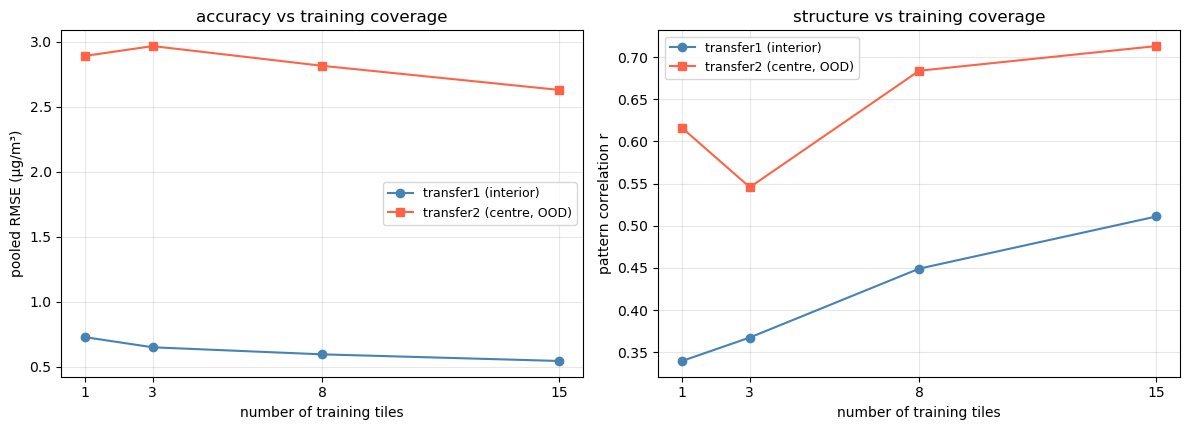

In [2]:
fig,axes=plt.subplots(1,2,figsize=(12,4.4))
axes[0].plot(N,r1,'o-',label='transfer1 (interior)',color='steelblue')
axes[0].plot(N,r2,'s-',label='transfer2 (centre, OOD)',color='tomato')
axes[0].set_xlabel('number of training tiles'); axes[0].set_ylabel('pooled RMSE (μg/m³)'); axes[0].set_title('accuracy vs training coverage')
axes[1].plot(N,p1,'o-',label='transfer1 (interior)',color='steelblue')
axes[1].plot(N,p2,'s-',label='transfer2 (centre, OOD)',color='tomato')
axes[1].set_xlabel('number of training tiles'); axes[1].set_ylabel('pattern correlation r'); axes[1].set_title('structure vs training coverage')
for ax in axes: ax.set_xticks(N); ax.grid(True,alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### Reading

- **Interior tile (transfer1)** improves **monotonically** with training coverage — RMSE
  0.729 → 0.546 (−25%) and r 0.34 → 0.51 from 1 to 15 tiles. Its concentrations are set by
  transport from the surroundings, so more spatial context directly helps.
- **Central-London tile (transfer2)** barely improves (RMSE stays 2.6–3.0, the 3v1 point is
  a noisy outlier). It is an extreme, source-dominated OOD block whose field is governed by
  its own strong local emissions, so extra training tiles add little — the transfer bottleneck
  is the out-of-distribution emission magnitude, not the amount of training data.